## 留意事項
* 本資料は教育・情報提供を目的としたものであり、特定の暗号資産・金融商品の売買、投資行動を推奨または勧誘するものではありません。
* 本資料に含まれる見解、分析、シミュレーション等は作成時点の情報および過去データ等に基づくものであり、その正確性・完全性を保証するものではありません。また、将来の成果・価格動向・収益等を保証するものではありません。
* 外部サービス名・製品名の記載は例示であり、主催者またはビットバンク株式会社による推奨、提携、保証を意味するものではありません。

## 注意事項
- 本ノートブックはAPI経由でデータを取得しています。Google Colabで実行する場合、地理的ブロックやレート制限等でエラ
能性があります。
- 配信中はセルを実行せず、一緒に出力結果を見ていきましょう！ 気になるところがあればチャットで質問してくださいね。

# はじめに

## 初心者botter会とは？
目的：botterを継続するためのきっかけつくり

対象：誰でも。特に非エンジニアの裁量トレーダーで自身の戦略を自動化したい人。

進め方：
1. スマトレ配信資料の振り返り
   * ほへとさんによるスマトレ配信を踏まえて、実際にりょうPさんが自分なりに分析した結果を共有します。
   * 分析には生成AIの力を借りて、配信だけでは網羅しにくいポイントについて、ほへとさんに補足・解説していただきます。
2. 複数指標でバックテスト
   * りょうPさんが1で扱った指標とほかの組み合わせて戦略をつくり、バックテストに挑戦します。



# 〜先物乖離編〜

#
# Part 1: 復習 

**日程**: 2026年2月26日 20:00〜21:00  
**参考**: ほへとさん第13回スマトレ「現物との価格乖離の分析①」  
- 動画: https://www.youtube.com/watch?v=9FOrGzPD26Q
- 資料: https://github.com/i-love-profit/smart_trading

## 今回やること

1. 先物乖離（Basis）の概念を振り返る
2. Binanceの現物・無期限先物データを取得し、乖離率を計算・可視化する
3. 乖離率・乖離変化・Z-Score がリターンとどう関係するかを確認する
4. 極端な乖離が起きたとき、その後どう動いたかを見る



## 先物乖離（Basis）とは

**現物取引**
- ビットコインの現物は様々な取引所で売買されている
- 現物 = ブロックチェーンに記録されているデータそのもの

**デリバティブ取引**
- レバレッジ取引・ヘッジ取引・戦略構築に使われる派生商品

**先物乖離（Basis）とは**
- デリバティブが買われる → 上乖離（デリバティブ価格 > 現物価格）
- デリバティブが売られる → 下乖離（デリバティブ価格 < 現物価格）

```
乖離率 = (先物終値 − 現物終値) ÷ 現物終値
```

**なぜ乖離が起きるのか？**
- 強気相場 → レバレッジロング増 → 上乖離
- 弱気相場 → ヘッジショート増 → 下乖離
- ほへとさん曰く「**人の欲望が現れる指標**」

**ポイント**
- 乖離が行き過ぎると平均に戻る傾向（平均乖離）
- Funding Rate という仕組みが乖離を縮小させる力として働く

### 用語まとめ

| 用語 | 意味 |
|---|---|
| **無期限先物（Perpetual）** | 期限のない先物契約。Binanceでは BTC/USDT:USDT として取引。 |
| **乖離率（Basis）** | (先物価格 − 現物価格) ÷ 現物価格。＋なら先物が割高。 |
| **上乖離** | 先物 > 現物。市場が強気の状態。 |
| **下乖離** | 先物 < 現物。市場が弱気の状態。 |
| **Funding Rate** | 乖離を縮小させる仕組み。上乖離時はロングがショートに支払う。 |
| **ミーンリバージョン** | 行き過ぎた値が平均に戻ろうとする傾向。 |
| **Z-Score** | 「平均からどれだけ離れているか」を標準偏差の単位で表した値。 |

---

## 環境設定

In [2]:
%pip install ccxt japanize-matplotlib python-dateutil -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datetime import datetime, timedelta
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

try:
    import japanize_matplotlib
except ImportError:
    pass

import ccxt

warnings.simplefilter("ignore")

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

print("準備完了")

準備完了


## パラメータ

In [4]:
SYMBOL_SPOT = "BTC/USDT"
SYMBOL_PERP = "BTC/USDT:USDT"
TIMEFRAME = "1d"
FROM_DATE = "2021-01-01"  # ほへとさん第13回と開始日を揃える
# この取り消し線は、Pylanceが型チェックして非推奨と判断したから
# 下のものが現推奨の書き方
# from datetime import datetime, timezone
# DAYS = (datetime.now(timezone.utc) - datetime.strptime(FROM_DATE, "%Y-%m-%d").replace(tzinfo=timezone.utc)).days + 1
# また、strptime()はstr型をdatetime型に変換するメソッド
# 名前の由来は string parse time。逆に datetime → strは strftime（string format time）。
# datetime 同士を引くと timedelta 型が返ってきて、.daysで日数だけ取り出している
# 最後に+1しているのは、開始日当日を含ませるため
DAYS = (datetime.utcnow() - datetime.strptime(FROM_DATE, "%Y-%m-%d")).days + 1

ZSCORE_WINDOW = 14

print(f"取得期間: {FROM_DATE} 〜 今日 ({DAYS}日分)")

取得期間: 2021-01-01 〜 今日 (1994日分)


---

## データ取得

In [5]:
def fetch_ohlcv(symbol, timeframe, days, market_type="spot"):
    """ccxt で Binance の OHLCV データを取得する"""
    # タイプが先物なら "binanceusdm"、現物なら "binance"
    exchange_id = "binanceusdm" if market_type == "swap" else "binance"
    # getattr(object, name) は オブジェクトの属性を文字列で取り出す関数
    # この2つは同じ意味
    # exchange = ccxt.binance({"enableRateLimit": True})
    # exchange = getattr(ccxt, "binance")({"enableRateLimit": True})
    # 今回getattrを使わないと、変数を使えないのでこの書き方をしている
    exchange = getattr(ccxt, exchange_id)({"enableRateLimit": True})
    # 現在から、現在から始点までの日数を引いて、取得するデータの始点を出し、
    # エポック秒にし、1000を掛けて、ミリ秒に変換している
    since = int((datetime.utcnow() - timedelta(days=days)).timestamp() * 1000)
    all_ohlcv = []
    while True:
        # このfetch_ohlcvは、ccxtのExchangeクラスのメソッド
        # batch = 一束、一団、ひとまとまり、1回分
        # プログラミング全般で「バッチ処理」というと、「一度にまとめて処理する単位」を batch と呼ぶ
        # ccxtはlistのlistでかえってくる
        batch = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        if not batch:
            break
        all_ohlcv.extend(batch)
        # listの最後のlistの[0]、つまり、timestamp それに1ミリ秒足している
        since = batch[-1][0] + 1
        # batchが1000以下ならデータを取りきったということなのでbreak
        if len(batch) < 1000:
            break

    # print(all_ohlcv) を確認して、ちゃんとtimestamp+OHLCVのリストのリストになっている
    df = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("datetime").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    label = f"{symbol} ({market_type})"
    print(f"✅ {label} {timeframe} x {len(df)}本 ({df.index[0].date()} 〜 {df.index[-1].date()})")
    return df

In [6]:
df_spot = fetch_ohlcv(SYMBOL_SPOT, TIMEFRAME, DAYS, market_type="spot")
df_perp = fetch_ohlcv(SYMBOL_PERP, TIMEFRAME, DAYS, market_type="swap")

display(df_spot)

✅ BTC/USDT (spot) 1d x 1995本 (2020-12-31 〜 2026-06-17)
✅ BTC/USDT:USDT (swap) 1d x 1995本 (2020-12-31 〜 2026-06-17)


,timestamp,open,high,low,close,volume
datetime,,,,,,
2020-12-31 00:00:00+00:00,1609372800000,28875.55,29300.00,27850.00,28923.63,75508.505152
2021-01-01 00:00:00+00:00,1609459200000,28923.63,29600.00,28624.57,29331.69,54182.925011
2021-01-02 00:00:00+00:00,1609545600000,29331.70,33300.00,28946.53,32178.33,129993.873362
2021-01-03 00:00:00+00:00,1609632000000,32176.45,34778.11,31962.99,33000.05,120957.566750
2021-01-04 00:00:00+00:00,1609718400000,33000.05,33600.00,28130.00,31988.71,140899.885690
...,...,...,...,...,...,...
2026-06-13 00:00:00+00:00,1781308800000,63580.00,64762.77,63418.66,64458.01,9960.741630
2026-06-14 00:00:00+00:00,1781395200000,64458.01,65800.00,63678.83,65746.45,13203.033750
2026-06-15 00:00:00+00:00,1781481600000,65746.45,67292.15,65354.00,66328.74,18559.801020


---

## 乖離率の計算

In [7]:
# intersection = 交差点
# intersection(index)で引数とメソッド元のインスタンスの両方あるindexの行のみを返す
# 要するに、2つのインデックスの**共通部分（積集合）**を返すメソッド
# ちなみに、
# 和集合（∪）: どちらかに含まれる全要素
# 差集合（-）: 片方にだけある要素
df = pd.DataFrame(index=df_spot.index.intersection(df_perp.index))
df["spot_close"] = df_spot.loc[df.index, "close"]
df["perp_close"] = df_perp.loc[df.index, "close"]
df = df.dropna()

df["deviation"] = (df["perp_close"] - df["spot_close"]) / df["spot_close"]
# pct_changeで前の行との変化率を返す
df["spot_ror"] = df["spot_close"].pct_change()
df["perp_ror"] = df["perp_close"].pct_change()
df["deviation_diff"] = df["deviation"].diff()

# rolling(1)は1行のみしか参照せず、自分のことを指すので意味がない
rolling_mean = df["deviation"].rolling(ZSCORE_WINDOW).mean()
rolling_std = df["deviation"].rolling(ZSCORE_WINDOW).std()
df["deviation_zscore"] = (df["deviation"] - rolling_mean) / rolling_std

print(f"統合データ: {len(df)}日分 ({df.index[0].date()} 〜 {df.index[-1].date()})")
df[["spot_close", "perp_close", "deviation", "deviation_zscore"]].tail()

統合データ: 1995日分 (2020-12-31 〜 2026-06-17)


,spot_close,perp_close,deviation,deviation_zscore
datetime,,,,
2026-06-13 00:00:00+00:00,64458.01,64418.2,-0.000618,-1.357978
2026-06-14 00:00:00+00:00,65746.45,65702.1,-0.000675,-1.645745
2026-06-15 00:00:00+00:00,66328.74,66285.9,-0.000646,-1.396737
2026-06-16 00:00:00+00:00,65675.01,65644.8,-0.000460,0.793099
2026-06-17 00:00:00+00:00,65574.00,65537.7,-0.000554,-0.193886


---

## 可視化: 乖離の推移

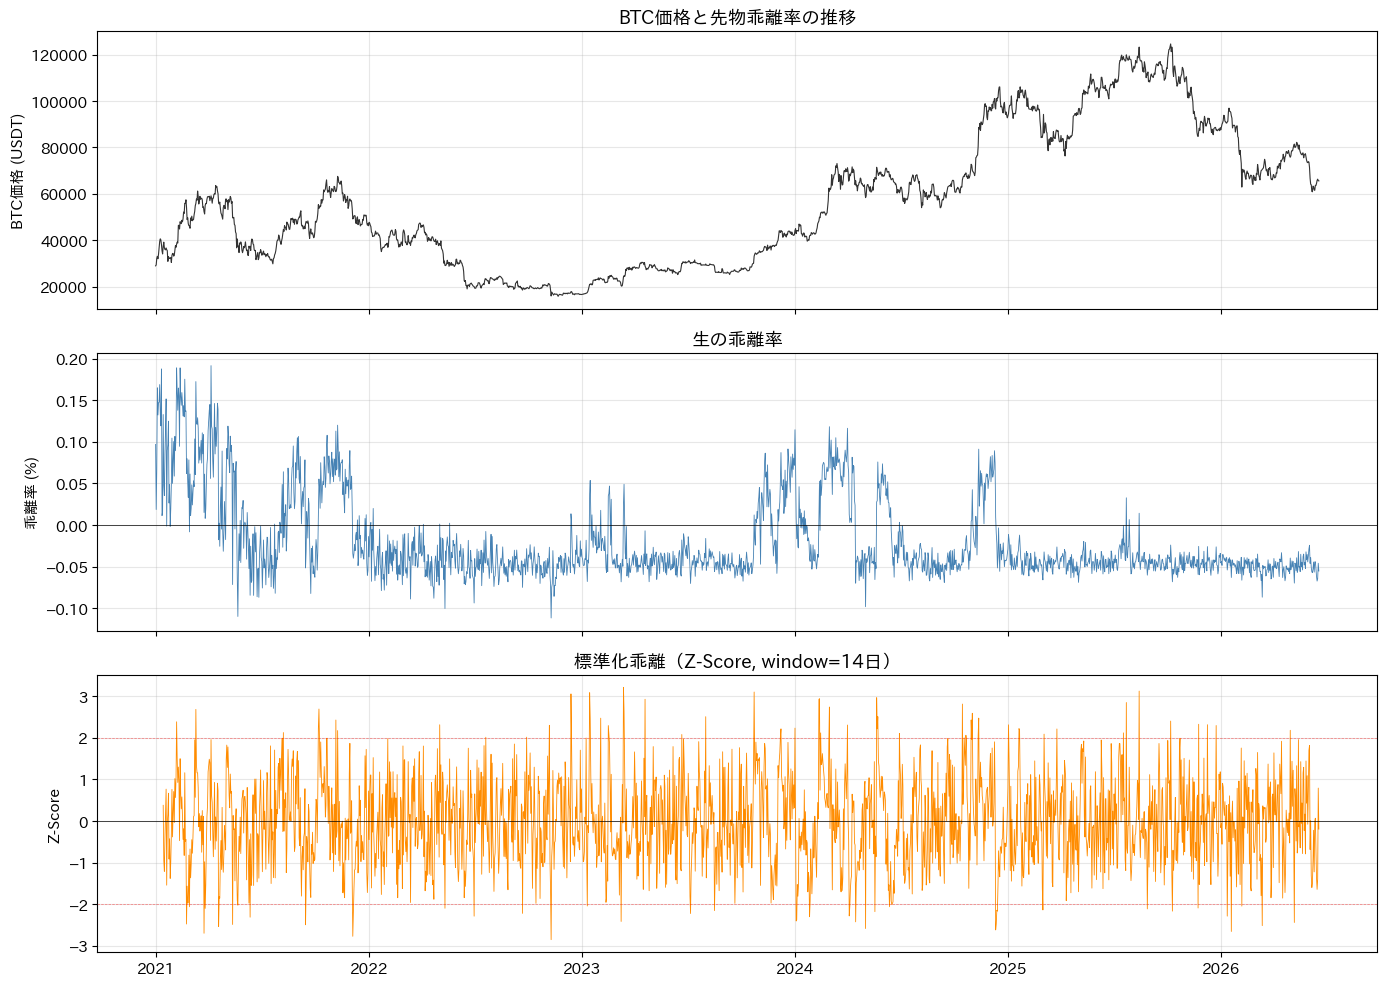

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["spot_close"], lw=0.8, color="#333")
axes[0].set_ylabel("BTC価格 (USDT)")
axes[0].set_title("BTC価格と先物乖離率の推移")

axes[1].plot(df.index, df["deviation"] * 100, lw=0.6, color="steelblue")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("乖離率 (%)")
axes[1].set_title("生の乖離率")

axes[2].plot(df.index, df["deviation_zscore"], lw=0.6, color="darkorange")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].axhline(2, color="r", lw=0.5, ls="--", alpha=0.5)
axes[2].axhline(-2, color="r", lw=0.5, ls="--", alpha=0.5)
axes[2].set_ylabel("Z-Score")
axes[2].set_title(f"標準化乖離（Z-Score, window={ZSCORE_WINDOW}日）")

fig.tight_layout()
plt.show()

---

## 基本統計

In [9]:
dev_pct = df["deviation"] * 100
print("=== 乖離率の基本統計 ===")
print(f"  平均      : {dev_pct.mean():+.4f}%")
print(f"  中央値    : {dev_pct.median():+.4f}%")
print(f"  標準偏差  : {dev_pct.std():.4f}%")
print(f"  最大(上乖離): {dev_pct.max():+.4f}%")
print(f"  最小(下乖離): {dev_pct.min():+.4f}%")
print(f"  上乖離の日数: {(df['deviation'] > 0).sum()}日 ({(df['deviation'] > 0).mean()*100:.1f}%)")
print(f"  下乖離の日数: {(df['deviation'] < 0).sum()}日 ({(df['deviation'] < 0).mean()*100:.1f}%)")

=== 乖離率の基本統計 ===
  平均      : -0.0197%
  中央値    : -0.0400%
  標準偏差  : 0.0493%
  最大(上乖離): +0.1918%
  最小(下乖離): -0.1119%
  上乖離の日数: 456日 (22.9%)
  下乖離の日数: 1539日 (77.1%)


---

## 乖離とリターンの関係

### 仮説1: 上乖離のとき価格は上昇トレンドにあるか？

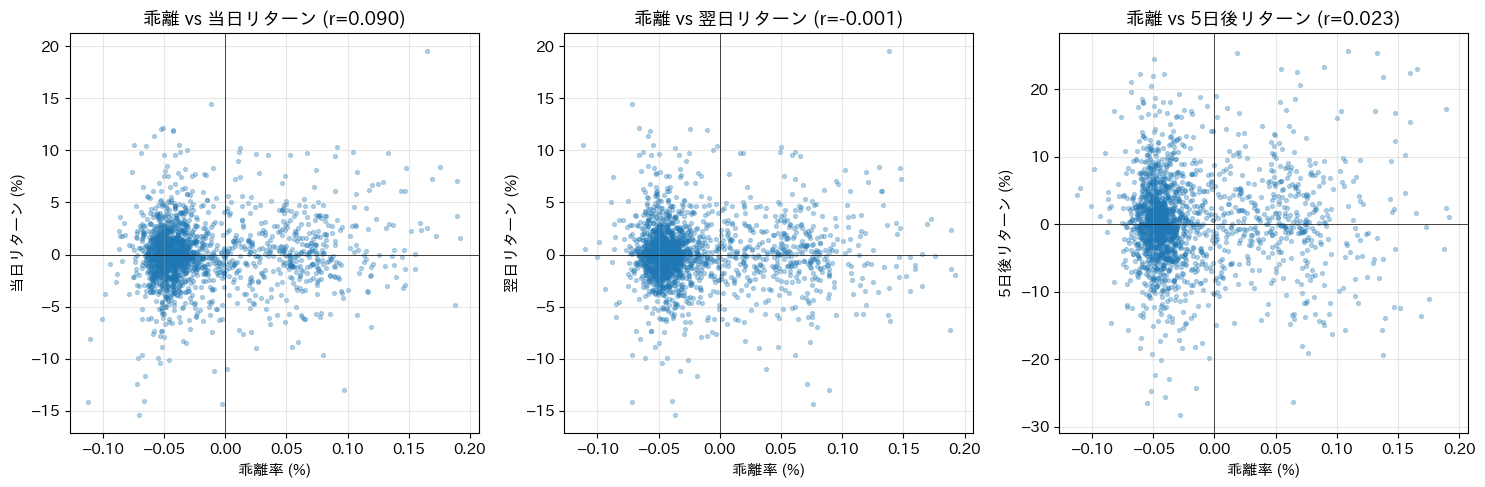

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# deviationとspot_rorの列がNaNの行はこの比較では無効にしておく
valid = df.dropna(subset=["deviation", "spot_ror"])

for i, (lag, label) in enumerate([(0, "当日"), (1, "翌日"), (5, "5日後")]):
    if lag == 0:
        future_ror = valid["spot_ror"]
    elif lag == 1:
        future_ror = valid["spot_ror"].shift(-1)
    else:
        future_ror = valid["spot_close"].pct_change(lag).shift(-lag)

    # validとfuture_rorのどちらにも存在するindexのみtrueのマスク
    mask = valid.index.intersection(future_ror.dropna().index)
    x = valid.loc[mask, "deviation"] * 100
    y = future_ror.loc[mask] * 100
    corr = x.corr(y)
    axes[i].scatter(x, y, alpha=0.3, s=8)
    axes[i].axhline(0, color="k", lw=0.5)
    axes[i].axvline(0, color="k", lw=0.5)
    axes[i].set_xlabel("乖離率 (%)")
    axes[i].set_ylabel(f"{label}リターン (%)")
    axes[i].set_title(f"乖離 vs {label}リターン (r={corr:.3f})")

fig.tight_layout()
plt.show()

### 仮説2: 乖離が急拡大したあと、逆方向に戻るか？（ミーンリバージョン）

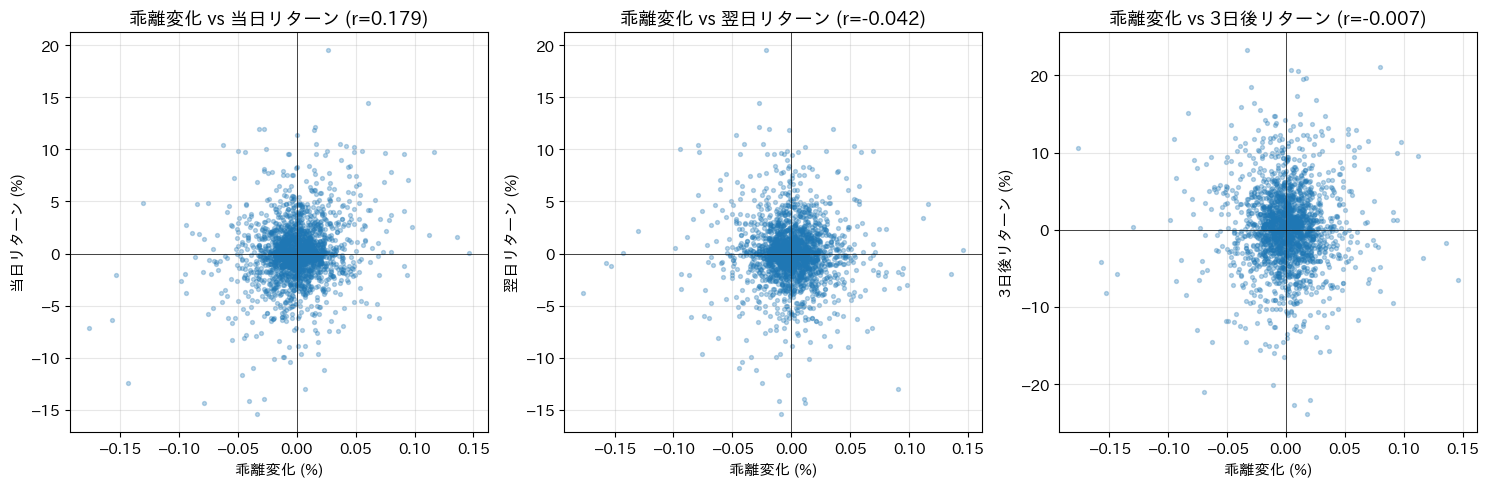

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
valid = df.dropna(subset=["deviation_diff", "spot_ror"])

for i, (lag, label) in enumerate([(0, "当日"), (1, "翌日"), (3, "3日後")]):
    if lag == 0:
        future_ror = valid["spot_ror"]
    elif lag == 1:
        future_ror = valid["spot_ror"].shift(-1)
    else:
        future_ror = valid["spot_close"].pct_change(lag).shift(-lag)
    mask = valid.index.intersection(future_ror.dropna().index)
    x = valid.loc[mask, "deviation_diff"] * 100
    y = future_ror.loc[mask] * 100
    corr = x.corr(y)
    axes[i].scatter(x, y, alpha=0.3, s=8)
    axes[i].axhline(0, color="k", lw=0.5)
    axes[i].axvline(0, color="k", lw=0.5)
    axes[i].set_xlabel("乖離変化 (%)")
    axes[i].set_ylabel(f"{label}リターン (%)")
    axes[i].set_title(f"乖離変化 vs {label}リターン (r={corr:.3f})")

fig.tight_layout()
plt.show()

### 仮説3: Z-Score は生の乖離より有効か？

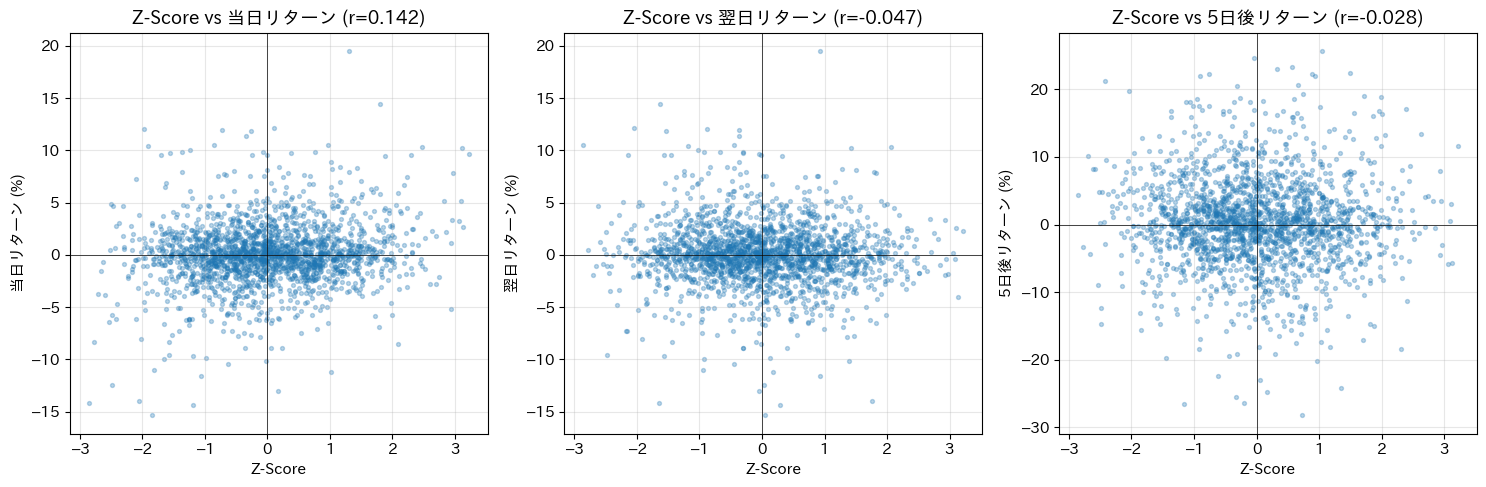

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
valid = df.dropna(subset=["deviation_zscore", "spot_ror"])

for i, (lag, label) in enumerate([(0, "当日"), (1, "翌日"), (5, "5日後")]):
    if lag == 0:
        future_ror = valid["spot_ror"]
    elif lag == 1:
        future_ror = valid["spot_ror"].shift(-1)
    else:
        future_ror = valid["spot_close"].pct_change(lag).shift(-lag)

    mask = valid.index.intersection(future_ror.dropna().index)
    x = valid.loc[mask, "deviation_zscore"]
    y = future_ror.loc[mask] * 100
    corr = x.corr(y)
    axes[i].scatter(x, y, alpha=0.3, s=8)
    axes[i].axhline(0, color="k", lw=0.5)
    axes[i].axvline(0, color="k", lw=0.5)
    axes[i].set_xlabel("Z-Score")
    axes[i].set_ylabel(f"{label}リターン (%)")
    axes[i].set_title(f"Z-Score vs {label}リターン (r={corr:.3f})")

fig.tight_layout()
plt.show()

In [13]:
next_ror = df["spot_ror"].shift(-1)
print("=== 翌日リターンとの相関係数（比較）===")
print(f"  生の乖離    : {df['deviation'].corr(next_ror):+.4f}")
print(f"  乖離変化    : {df['deviation_diff'].corr(next_ror):+.4f}")
print(f"  Z-Score     : {df['deviation_zscore'].corr(next_ror):+.4f}")

=== 翌日リターンとの相関係数（比較）===
  生の乖離    : -0.0007
  乖離変化    : -0.0416
  Z-Score     : -0.0468


---

## 追加分析: 極端な乖離時の挙動

Z-Score が閾値を超えたとき、その後何日で反転したか？

In [14]:
# Zスコアの列にNaNがあるものは無効
valid = df.dropna(subset=["deviation_zscore"]).copy()

results = []
for th in [1.0, 1.5, 2.0]:
    for direction, label in [(1, "上乖離"), (-1, "下乖離")]:
        # 上乖離ならZスコアが+閾値を上回っていたらtrue、下乖離ならZスコアが-閾値を下回っていたらtrue、
        mask = valid["deviation_zscore"] > th if direction == 1 else valid["deviation_zscore"] < -th
        subset = valid[mask]  # マスク条件を満たす有効なものを抽出
        if len(subset) == 0:
            continue
        ror_1d = subset["spot_close"].pct_change(1).shift(-1).reindex(subset.index)
        ror_3d = subset["spot_close"].pct_change(3).shift(-3).reindex(subset.index)
        # 5日前のデータとの変化率を出し、それを5行前にずらし、その日から見た5日後のリターンにする
        # reindexでsubsetのindexに強制的に合わせる。ないindexの行はNaNになる。
        # intersectionと似てるが、これは両方にあるindexではなく、subsetのindexに合わせる
        ror_5d = subset["spot_close"].pct_change(5).shift(-5).reindex(subset.index)
        rev_1d = (ror_1d < 0).mean() * 100 if direction == 1 else (ror_1d > 0).mean() * 100
        rev_3d = (ror_3d < 0).mean() * 100 if direction == 1 else (ror_3d > 0).mean() * 100
        # 真偽値が1/0で扱われることを利用し、.mean()を使うことで、true/falseの割合が出せる
        # 上乖離なら5日後のリターンがマイナス、下乖離なら5日後のリターンがプラスになった割合
        rev_5d = (ror_5d < 0).mean() * 100 if direction == 1 else (ror_5d > 0).mean() * 100
        results.append(
            {
                "条件": f"Z-Score {'>' if direction==1 else '<'} {'+' if direction==1 else '-'}{th}",
                "方向": label,
                "発生回数": len(subset),
                "翌日反転率": f"{rev_1d:.1f}%",
                "3日後反転率": f"{rev_3d:.1f}%",
                "5日後反転率": f"{rev_5d:.1f}%",
                "翌日平均リターン": f"{ror_1d.mean()*100:+.2f}%",
            }
        )

pd.DataFrame(results)

,条件,方向,発生回数,翌日反転率,3日後反転率,5日後反転率,翌日平均リターン
0,Z-Score > +1.0,上乖離,342,42.7%,41.8%,39.8%,+0.43%
1,Z-Score < -1.0,下乖離,341,50.4%,49.9%,47.8%,+0.49%
2,Z-Score > +1.5,上乖離,152,42.1%,37.5%,33.6%,+0.93%
3,Z-Score < -1.5,下乖離,148,50.7%,52.0%,49.3%,+1.16%
4,Z-Score > +2.0,上乖離,55,30.9%,30.9%,29.1%,+2.56%
5,Z-Score < -2.0,下乖離,42,59.5%,50.0%,45.2%,+3.22%


,mean,count
zscore_bin,,
<-2,0.005445,42
-2〜-1,0.003592,299
-1〜-0.5,0.002520,307
-0.5〜0.5,-0.000671,718
0.5〜1,0.000433,273
1〜2,-0.001392,287
>2,0.002582,55


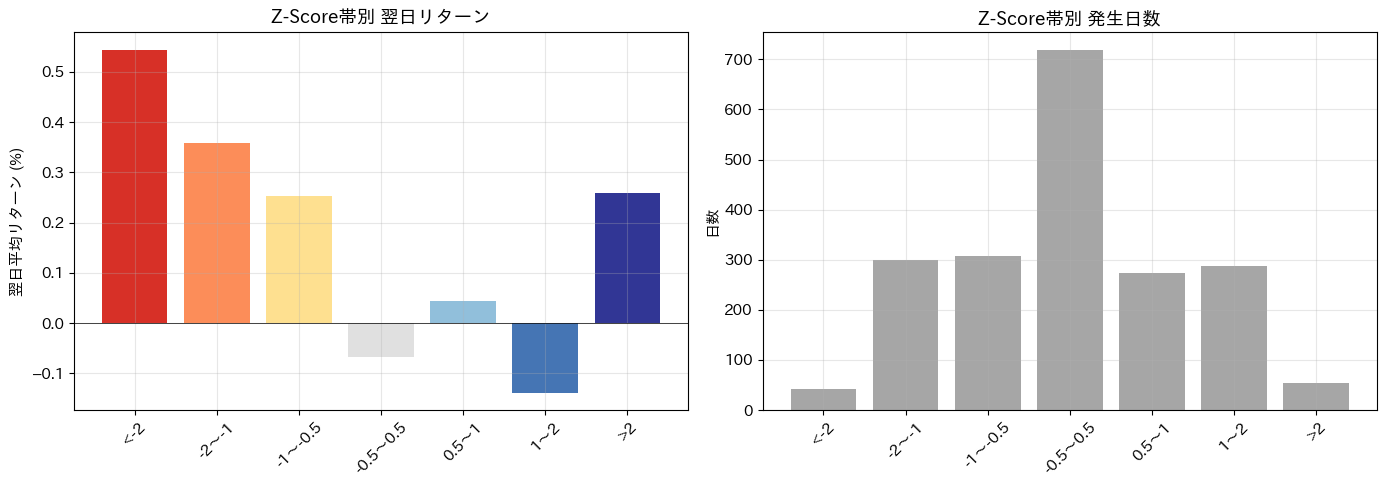

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = [-np.inf, -2, -1, -0.5, 0.5, 1, 2, np.inf]
labels = ["<-2", "-2〜-1", "-1〜-0.5", "-0.5〜0.5", "0.5〜1", "1〜2", ">2"]
# .cut()はbinsを区切りとして、labelを貼り付けてくれるメソッド
valid["zscore_bin"] = pd.cut(valid["deviation_zscore"], bins=bins, labels=labels)
valid["next_ror"] = valid["spot_ror"].shift(-1)
# "zscore_bin"でグループ分けして、"next_ror"の列だけ取り出し、aggでグループに対してまとめて計算
bin_stats = valid.groupby("zscore_bin")["next_ror"].agg(["mean", "count"])
display(bin_stats)

colors = ["#d73027", "#fc8d59", "#fee090", "#e0e0e0", "#91bfdb", "#4575b4", "#313695"]
axes[0].bar(range(len(bin_stats)), bin_stats["mean"] * 100, color=colors)
axes[0].set_xticks(range(len(bin_stats)))
axes[0].set_xticklabels(labels, rotation=45)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("翌日平均リターン (%)")
axes[0].set_title("Z-Score帯別 翌日リターン")

axes[1].bar(range(len(bin_stats)), bin_stats["count"], color="gray", alpha=0.7)
axes[1].set_xticks(range(len(bin_stats)))
axes[1].set_xticklabels(labels, rotation=45)
axes[1].set_ylabel("日数")
axes[1].set_title("Z-Score帯別 発生日数")

fig.tight_layout()
plt.show()

---

## 仮説検証: Z-Score逆張りで損益曲線を引く

「Z-Scoreが高い（上乖離しすぎ）→ ショート、低い（下乖離しすぎ）→ ロング」
という単純なルールで実際に損益曲線を引いてみる。

**ほへとさん資料（第13回）の戦略3と同じアプローチ。**

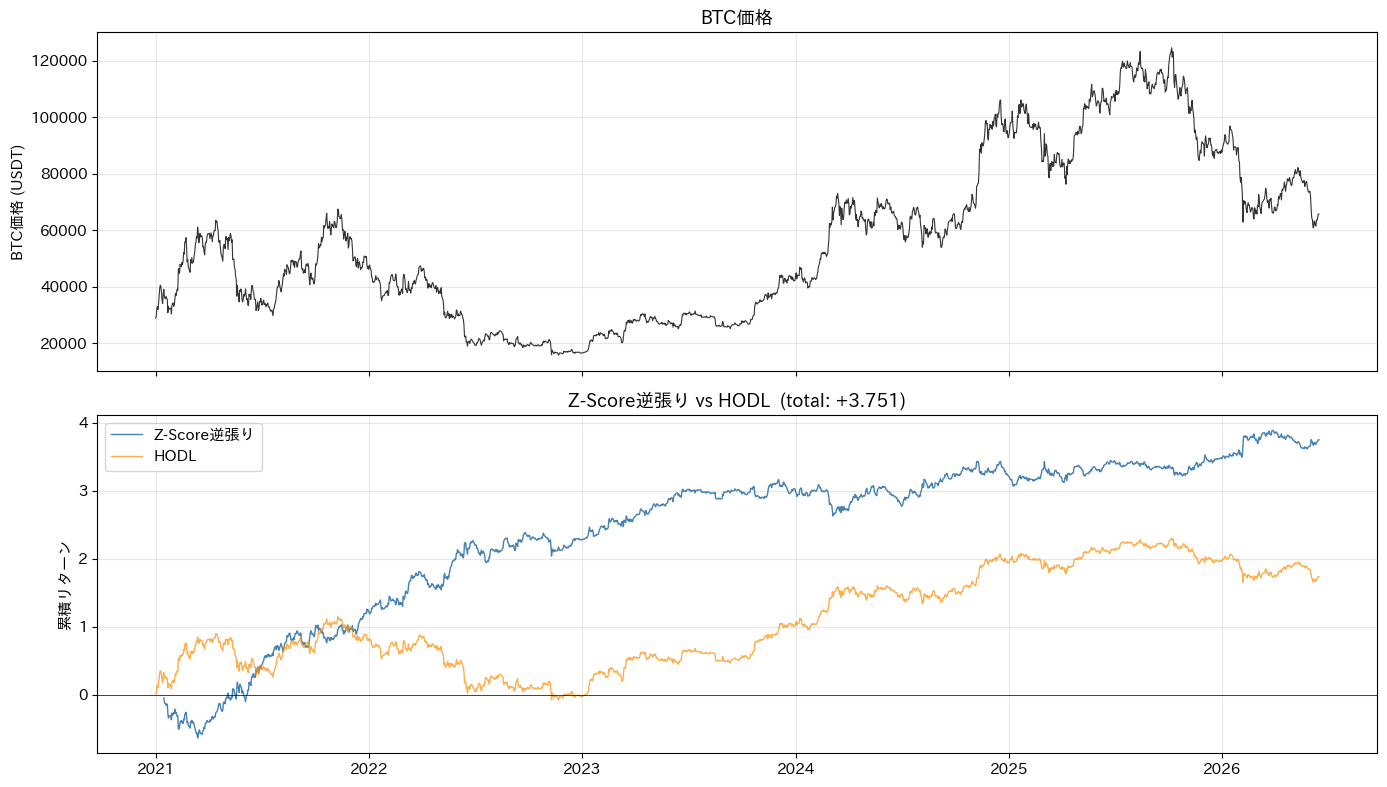

勝率    : 51.5%
累積    : +3.7507
シャープ: +1.002


In [ ]:
strategy = df.copy()

# 前日のZ-Scoreがプラス（上乖離）→ ショート(-1)、マイナス（下乖離）→ ロング(+1)
strategy["signal"] = -np.sign(strategy["deviation_zscore"].shift(1))
strategy["pnl"] = strategy["perp_ror"] * strategy["signal"]
strategy["hodl"] = strategy["perp_ror"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(strategy.index, strategy["spot_close"], lw=0.8, color="#333")
axes[0].set_ylabel("BTC価格 (USDT)")
axes[0].set_title("BTC価格")

cumulative = strategy["pnl"].cumsum()
cumulative_hodl = strategy["hodl"].cumsum()
axes[1].plot(strategy.index, cumulative, lw=1.0, color="steelblue", label="Z-Score逆張り")
axes[1].plot(strategy.index, cumulative_hodl, lw=1.0, color="darkorange", label="HODL", alpha=0.7)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].legend()
axes[1].set_ylabel("累積リターン")
axes[1].set_title(f"Z-Score逆張り vs HODL  (total: {cumulative.iloc[-1]:+.3f})")

fig.tight_layout()
plt.show()

win_rate = (strategy["pnl"] > 0).mean() * 100
print(f"勝率    : {win_rate:.1f}%")
print(f"累積    : {cumulative.iloc[-1]:+.4f}")
# シャープレシオは　(年次平均リターン/年次標準偏差(リスク))
# これは日足を使っているので、
# 年次リターン = 日次リターン * 252(年間営業日)
# 年次標準偏差 = 日次標準偏差 * √252　(年次分散は*252で出るからその平方根の標準偏差は * √252)
# だから、下のような式になる
sharpe = strategy["pnl"].mean() / strategy["pnl"].std() * (252**0.5)
print(f"シャープ: {sharpe:+.3f}")

---

## まとめ

In [16]:
next_ror = df["spot_ror"].shift(-1)
next5_ror = df["spot_close"].pct_change(5).shift(-5)

corr_h1 = df["deviation"].corr(df["spot_ror"])
corr_h2 = df["deviation_diff"].corr(next_ror)
corr_z1 = df["deviation_zscore"].corr(next_ror)
corr_raw1 = df["deviation"].corr(next_ror)

h1_result = "✅ 支持" if abs(corr_h1) > 0.1 else "❌ 棄却"
h2_result = "✅ 支持" if corr_h2 < -0.05 else ("❌ 棄却" if corr_h2 > 0.05 else "△ 弱い")
h3_result = "✅ 支持" if abs(corr_z1) > abs(corr_raw1) else "❌ 棄却"

print(f"直近{DAYS}日間（{df.index[0].date()} 〜 {df.index[-1].date()}）の検証結果")
print()
print("| 仮説                         | 結果 |")
print("|---|---|")
print(f"| 1. 上乖離 = 上昇トレンド     | r={corr_h1:+.3f} → {h1_result} |")
print(f"| 2. 乖離急拡大 → 逆行         | r={corr_h2:+.3f} → {h2_result} |")
print(
    f"| 3. Z-Score のほうが有効      | raw r={corr_raw1:+.3f} vs z r={corr_z1:+.3f} → {h3_result} |"
)
print()
print("ほへとさん第13回の結論: 『デリバティブとの価格乖離は、使えそうな指標としてストック』")

直近1992日間（2020-12-31 〜 2026-06-15）の検証結果

| 仮説                         | 結果 |
|---|---|
| 1. 上乖離 = 上昇トレンド     | r=+0.091 → ❌ 棄却 |
| 2. 乖離急拡大 → 逆行         | r=-0.042 → △ 弱い |
| 3. Z-Score のほうが有効      | raw r=-0.001 vs z r=-0.047 → ✅ 支持 |

ほへとさん第13回の結論: 『デリバティブとの価格乖離は、使えそうな指標としてストック』


## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断をもってお取引を行ってください。
* 暗号資産取引に関するリスク等の詳細および諸条件は、bitbank利用規約等をご確認ください：https://bitbank.cc/doc/tos

 登録：暗号資産交換業者 登録番号 第00004号、貸金業者 登録番号 東京都知事（２） 第31821号
 
 加入：一般社団法人 日本暗号資産等取引業協会、一般社団法人 日本暗号資産ビジネス協会、一般社団法人 JPCrypto-ISAC、日本貸金業協会会員 第006169号、株式会社日本信用情報機構(JICC)